In [ ]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import binom
from scipy.stats import chisquare

from collections import Counter

# Redes de Mundo pequeño

In [ ]:
#parametros
n = 20
k = 10
p = 0.2

Small-World con NetworkX

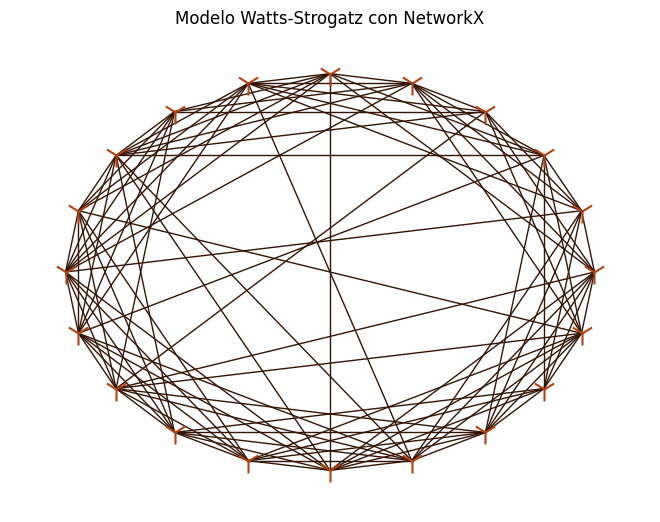

In [ ]:
G_small_networkx = nx.watts_strogatz_graph(n, k, p)

#visualizacion
pos = nx.circular_layout(G_small_networkx)

nx.draw(G_small_networkx,
        pos,
        node_size=300,
        with_labels=False,
        node_color="#b34212",
        edge_color="#341405",
        node_shape='1'
        )
plt.title("Modelo Watts-Strogatz con NetworkX")
plt.show()

Small-world reconectando enlaces

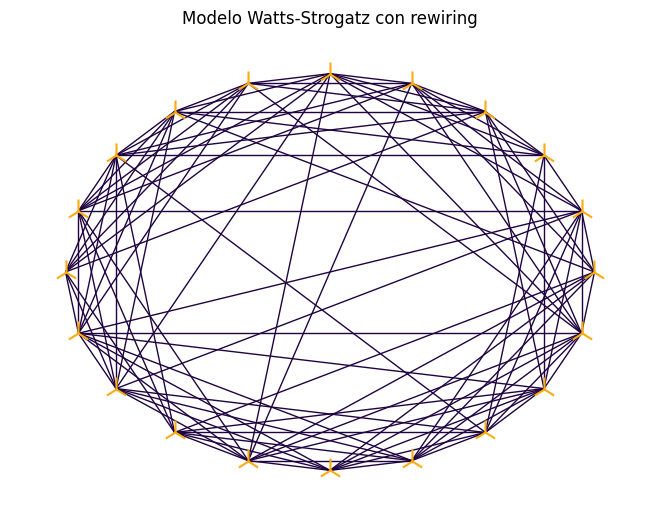

In [ ]:
G_rewiring = nx.Graph()
G_rewiring.add_nodes_from(range(n))

#Red anillo regular
for i in range(n):
    for j in range(1, k//2 + 1):
        G_rewiring.add_edge(i, (i + j) % n)

#Rewiring
for i in range(n):
    for j in range(1, k//2 + 1):
        neighbor = (i + j) % n

        if random.random() < p:
            G_rewiring.remove_edge(i, neighbor)

            possible_nodes = list(set(range(n)) - {i} - set(G_rewiring.neighbors(i)))
            new_neighbor = random.choice(possible_nodes)
            G_rewiring.add_edge(i, new_neighbor)

pos = nx.circular_layout(G_rewiring)
nx.draw(G_rewiring,
        pos,
        node_size=300,
        with_labels=False,
        node_color="#fcab10",
        edge_color="#1f0441",
        node_shape='2'
        )
plt.title("Modelo Watts-Strogatz con rewiring")
plt.show()

Small-world dejando intacto el "*ring lattice*" y añadiendo enlaces extra como *shortcuts*

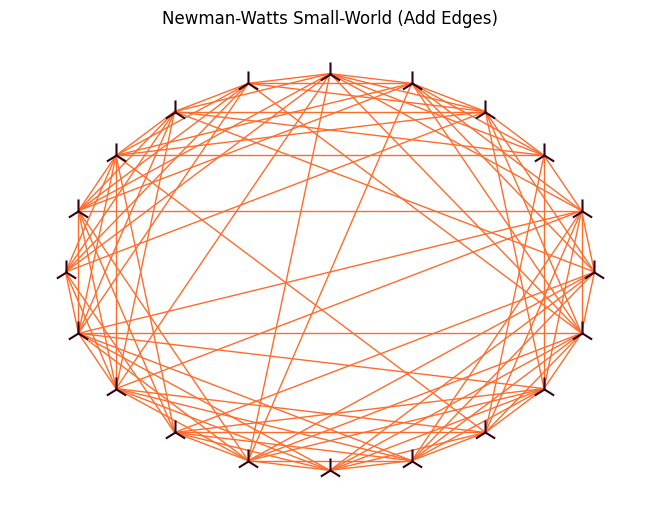

In [ ]:
#parametros
p = 0.05

G_small_new = nx.Graph()
G_small_new.add_nodes_from(range(n))

#Red anillo regular
for i in range(n):
    for j in range(1, k//2 + 1):
        G_small_new.add_edge(i, (i + j) % n)

#Enlaces aleatorios sin eliminar existentes
for i in range(n):
    for j in range(i+1, n):
        if not G_small_new.has_edge(i, j):
            if random.random() < p:
                G_small_new.add_edge(i, j)

pos = nx.circular_layout(G_small_new)
nx.draw(G_rewiring,
        pos,
        node_size=300,
        with_labels=False,
        node_color="#340016",
        edge_color="#fe6c2b",
        node_shape='2'
        )
plt.title("Newman-Watts Small-World (Add Edges)")
plt.show()

In [ ]:
def analizar_red(G, nombre):
    print(f"\n--- {nombre} ---")

    clustering = nx.average_clustering(G)
    print(f"Clustering promedio: {clustering:.4f}")

    avg_path = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)
    print(f"Longitud promedio de camino: {avg_path:.4f}")
    print(f"Diametro: {diameter}")

analizar_red(G_small_networkx, "Small-World NetworkX")
analizar_red(G_rewiring, "Small-World Manual Rewiring")
analizar_red(G_small_new, "Small-World Añadiendo Shortcuts")


--- Small-World NetworkX ---
Clustering promedio: 0.5535
Longitud promedio de camino: 1.4789
Diametro: 3

--- Small-World Manual Rewiring ---
Clustering promedio: 0.5507
Longitud promedio de camino: 1.4737
Diametro: 2

--- Small-World Añadiendo Shortcuts ---
Clustering promedio: 0.6629
Longitud promedio de camino: 1.4632
Diametro: 2


Comprobar que las redes sean de mundo pequeño con los coeficientes sigma y omega

In [ ]:
def small_world_metrics(G, name):
    sigma = nx.sigma(G, niter=10, nrand=10)
    omega = nx.omega(G, niter=10, nrand=10)

    print(f"\n--- {name} ---")
    print(f"Sigma: {sigma:.4f}")
    print(f"Omega: {omega:.4f}")

    return sigma, omega


sigma_nx, omega_nx = small_world_metrics(G_small_networkx, "Small-World NetworkX")
sigma_manual, omega_manual = small_world_metrics(G_rewiring, "Small-World Manual Rewiring")
sigma_newman, omega_newman = small_world_metrics(G_small_new, "Small-World Newman-Watts")


--- Small-World NetworkX ---
Sigma: 1.1197
Omega: -0.0036

--- Small-World Manual Rewiring ---
Sigma: 1.1096
Omega: 0.0004

--- Small-World Newman-Watts ---
Sigma: 1.3782
Omega: 0.0000


**Análisis de Mundo Pequeño**

**Sigma (σ)**  

$\sigma = \frac{C/C_{rand}}{L/L_{rand}}$

Si σ > 1, la red presenta comportamiento de mundo pequeño.   

Esta métrica indica que la red tiene alto clustering comparado con una red aleatoria, pero mantiene longitudes de camino similares a ella.

**Omega (ω)**  

$\omega = \frac{L_{rand}}{L} - \frac{C}{C_{latt}}$

Si ω ≈ 0, la red es mundo pequeño.  
Si ω < 0, se comporta como red regular (lattice).  
Si ω > 0, se comporta como red aleatoria.

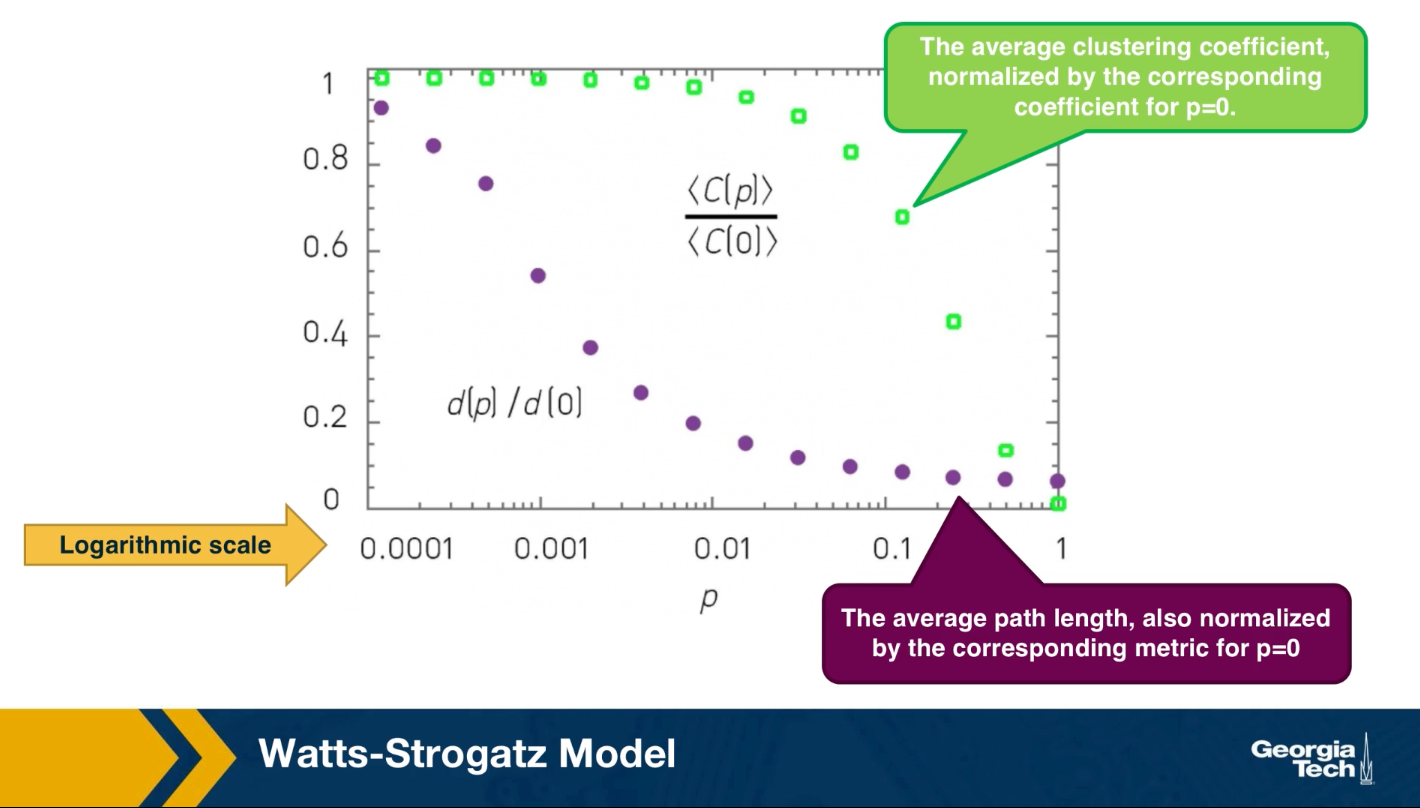